# 02 — Fundamentals

**Étape 3 — Fondamentaux (demande, production, nucléaire, interconnexions)**

Compléter la collecte avec les fondamentaux du système électrique français :
demande réalisée, production par filière (nucléaire, hydraulique, éolien, solaire),
disponibilité/capacité, et échanges transfrontaliers.

Sources : RTE APIs (`src/data.py::fetch_rte_actual_generation`, `fetch_rte_consumption`)
ou ENTSO-E (`fetch_entsoe_load_and_generation`) pour une couverture européenne.


## Setup

In [3]:
from pathlib import Path
from io import BytesIO
import sys
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path(
    "/Users/evitafaj/Desktop/Portofolio/"
    "electricity-price-forecasting"
)

RAW_DIR = REPO_ROOT / "data" / "raw"
PRICE_PATH = RAW_DIR / "entsoe_day_ahead_prices_fr.csv"

# Permet à Python de trouver src/
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import save_raw

# Période métier
START_DATE = "2022-01-01"
END_DATE = "2025-09-30"

# L'index des prix est la référence temporelle
price_data = pd.read_csv(
    PRICE_PATH,
    usecols=["datetime", "price_da"],
)

price_data["datetime"] = pd.to_datetime(
    price_data["datetime"],
    utc=True,
)

price_index = pd.DatetimeIndex(
    price_data["datetime"],
    name="datetime",
)

print("Racine du projet :", REPO_ROOT)
print("Fichier des prix :", PRICE_PATH)
print("Heures attendues :", len(price_index))
print("Début UTC :", price_index.min())
print("Fin UTC :", price_index.max())

Racine du projet : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting
Fichier des prix : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/data/raw/entsoe_day_ahead_prices_fr.csv
Heures attendues : 32855
Début UTC : 2021-12-31 23:00:00+00:00
Fin UTC : 2025-09-30 21:00:00+00:00


## Récupération de la demande réalisée (RTE ou ENTSO-E)

In [4]:
ECO2MIX_URL = (
    "https://odre.opendatasoft.com/api/explore/v2.1/"
    "catalog/datasets/eco2mix-national-cons-def/exports/csv"
)

FIELDS = [
    "date_heure",
    "consommation",
    "prevision_j1",
    "fioul",
    "charbon",
    "gaz",
    "nucleaire",
    "eolien",
    "solaire",
    "hydraulique",
    "pompage",
    "bioenergies",
    "ech_physiques",
]

params = {
    "select": ",".join(FIELDS),
    "where": (
        "date_heure >= date'2021-12-31T00:00:00Z' "
        "and date_heure < date'2025-10-02T00:00:00Z'"
    ),
    "order_by": "date_heure",
    "timezone": "UTC",
    "use_labels": "false",
    "delimiter": ";",
}

response = requests.get(
    ECO2MIX_URL,
    params=params,
    timeout=180,
)
response.raise_for_status()

eco2mix_raw = pd.read_csv(
    BytesIO(response.content),
    sep=";",
    encoding="utf-8-sig",
)

print("Dimensions brutes :", eco2mix_raw.shape)
eco2mix_raw.head()

Dimensions brutes : (131620, 13)


,date_heure,consommation,prevision_j1,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,ech_physiques
0,2021-12-31T00:00:00+00:00,50765.0,48400,92.0,14.0,2843.0,39168.0,5555.0,0.0,7870.0,-1708.0,1199.0,-4205.0
1,2021-12-31T00:15:00+00:00,NaN,48350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-12-31T00:30:00+00:00,50728.0,48300,91.0,13.0,2842.0,39202.0,5519.0,0.0,7853.0,-1482.0,1201.0,-4450.0
3,2021-12-31T00:45:00+00:00,NaN,48200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-12-31T01:00:00+00:00,50277.0,48100,91.0,13.0,2827.0,39069.0,5602.0,0.0,7960.0,-1837.0,1201.0,-4589.0


In [5]:
eco2mix_raw["datetime"] = pd.to_datetime(
    eco2mix_raw["date_heure"],
    utc=True,
)

numeric_columns = [column for column in FIELDS if column != "date_heure"]

for column in numeric_columns:
    eco2mix_raw[column] = pd.to_numeric(
        eco2mix_raw[column],
        errors="coerce",
    )

eco2mix_raw = (
    eco2mix_raw
    .set_index("datetime")
    .drop(columns=["date_heure"])
    .sort_index()
)

# Passage des données 15/30 minutes à une fréquence horaire
eco2mix_hourly = eco2mix_raw.resample("h").mean()

# Alignement exact sur les prix
eco2mix_hourly = eco2mix_hourly.reindex(price_index)
eco2mix_hourly.index.name = "datetime"

demand = eco2mix_hourly[
    ["consommation", "prevision_j1"]
].rename(
    columns={
        "consommation": "demand_actual",
        "prevision_j1": "demand_forecast_j1",
    }
)

print("Dimensions demande :", demand.shape)
print("Valeurs manquantes :")
print(demand.isna().sum())

demand.head()

Dimensions demande : (32855, 2)
Valeurs manquantes :
demand_actual         3
demand_forecast_j1    3
dtype: int64


,demand_actual,demand_forecast_j1
datetime,,
2021-12-31 23:00:00+00:00,54315.0,50787.5
2022-01-01 00:00:00+00:00,52173.5,49162.5
2022-01-01 01:00:00+00:00,51527.5,47550.0
2022-01-01 02:00:00+00:00,48845.5,44687.5
2022-01-01 03:00:00+00:00,46646.0,43075.0


## Récupération de la production par filière (nucléaire, éolien, solaire, hydraulique)

In [6]:
generation = eco2mix_hourly[
    [
        "nucleaire",
        "eolien",
        "solaire",
        "hydraulique",
        "gaz",
        "charbon",
        "fioul",
        "bioenergies",
        "pompage",
    ]
].rename(
    columns={
        "nucleaire": "nuclear_generation",
        "eolien": "wind_generation",
        "solaire": "solar_generation",
        "hydraulique": "hydro_generation",
        "gaz": "gas_generation",
        "charbon": "coal_generation",
        "fioul": "oil_generation",
        "bioenergies": "bioenergy_generation",
        "pompage": "pumping_consumption",
    }
)

print("Dimensions production :", generation.shape)
print("Valeurs manquantes :")
print(generation.isna().sum())

generation.head()

Dimensions production : (32855, 9)
Valeurs manquantes :
nuclear_generation      3
wind_generation         3
solar_generation        3
hydro_generation        3
gas_generation          3
coal_generation         3
oil_generation          3
bioenergy_generation    3
pumping_consumption     3
dtype: int64


,nuclear_generation,wind_generation,solar_generation,hydro_generation,gas_generation,coal_generation,oil_generation,bioenergy_generation,pumping_consumption
datetime,,,,,,,,,
2021-12-31 23:00:00+00:00,40497.0,3187.5,0.0,9465.5,2826.0,13.5,94.0,1247.5,-264.0
2022-01-01 00:00:00+00:00,38645.5,3270.0,0.0,9108.0,2693.0,13.5,99.0,1255.0,-65.0
2022-01-01 01:00:00+00:00,38081.0,3146.0,0.0,8427.0,2687.0,13.0,99.0,1250.5,-602.5
2022-01-01 02:00:00+00:00,37259.5,3273.5,0.0,6787.0,2694.0,13.0,99.0,1247.5,-1459.5
2022-01-01 03:00:00+00:00,36374.5,3481.5,0.0,6443.0,2699.5,13.0,99.0,1253.5,-2638.0


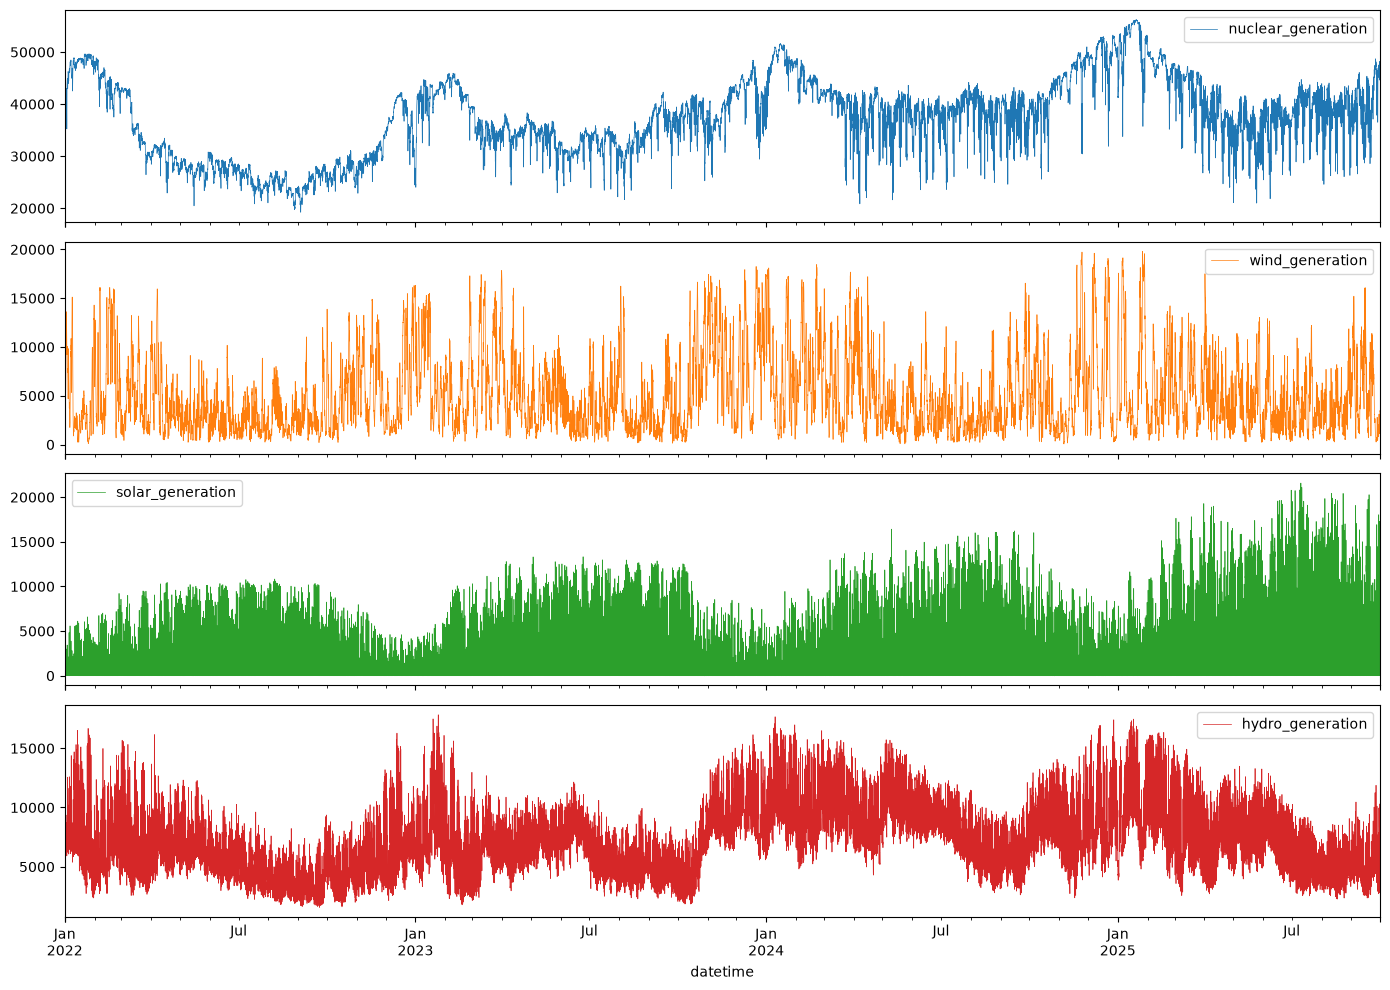

In [7]:
generation[
    [
        "nuclear_generation",
        "wind_generation",
        "solar_generation",
        "hydro_generation",
    ]
].plot(
    subplots=True,
    figsize=(14, 10),
    linewidth=0.5,
)

plt.tight_layout()
plt.show()

## Disponibilité / capacité indisponible (distinguer production observée vs capacité, section 4.1)

In [8]:
nuclear_availability = None

print(
    "Disponibilité nucléaire non collectée pour le moment. "
    "La production observée ne doit pas être interprétée "
    "comme une capacité disponible."
)

Disponibilité nucléaire non collectée pour le moment. La production observée ne doit pas être interprétée comme une capacité disponible.


## Échanges transfrontaliers (imports/exports, base pour les spreads section 6.4)

Dimensions échanges : (32855, 1)
Valeurs manquantes :
net_import_mw    3
dtype: int64


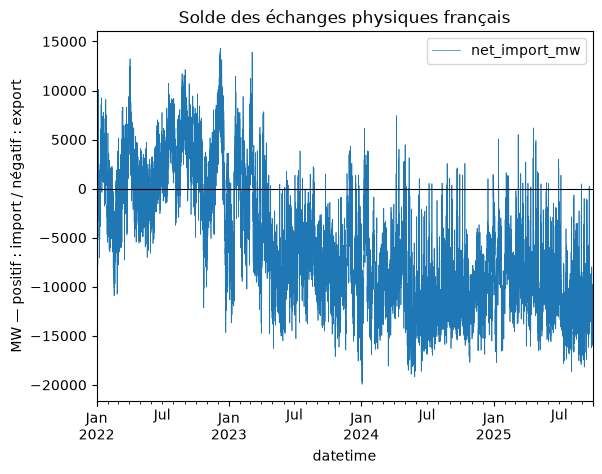

,net_import_mw
datetime,
2021-12-31 23:00:00+00:00,-2679.0
2022-01-01 00:00:00+00:00,-2768.5
2022-01-01 01:00:00+00:00,-1491.0
2022-01-01 02:00:00+00:00,-986.5
2022-01-01 03:00:00+00:00,-1001.0


In [9]:
exchanges = eco2mix_hourly[
    ["ech_physiques"]
].rename(
    columns={
        "ech_physiques": "net_import_mw",
    }
)

# Convention RTE :
# valeur positive = importateur net
# valeur négative = exportateur net

print("Dimensions échanges :", exchanges.shape)
print("Valeurs manquantes :")
print(exchanges.isna().sum())

exchanges.plot(
    title="Solde des échanges physiques français",
    linewidth=0.5,
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("MW — positif : import / négatif : export")
plt.show()

exchanges.head()

## Gaz et CO2 (prix de marché — documenter la source utilisée, section 6.1)

In [10]:
gas_price = None
co2_price = None

print(
    "Prix du gaz TTF et quotas CO2 EUA non collectés. "
    "Ils nécessitent des séries de marché séparées."
)

Prix du gaz TTF et quotas CO2 EUA non collectés. Ils nécessitent des séries de marché séparées.


In [11]:
missing_by_hour = eco2mix_hourly.isna().sum(axis=1)
missing_hours = missing_by_hour[missing_by_hour > 0]

print("Heures concernées :", len(missing_hours))
display(missing_hours)
display(eco2mix_hourly.loc[missing_hours.index])

Heures concernées : 3


datetime
2022-10-30 00:00:00+00:00    12
2023-10-29 00:00:00+00:00    12
2024-10-27 00:00:00+00:00    12
dtype: int64

,consommation,prevision_j1,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,ech_physiques
datetime,,,,,,,,,,,,
2022-10-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-29 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-10-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print(
    "Lignes entièrement manquantes :",
    eco2mix_hourly.isna().all(axis=1).sum(),
)

print(
    "Lignes partiellement manquantes :",
    (
        eco2mix_hourly.isna().any(axis=1)
        & ~eco2mix_hourly.isna().all(axis=1)
    ).sum(),
)

Lignes entièrement manquantes : 3
Lignes partiellement manquantes : 0


In [13]:
# Indicateur permettant de retrouver les valeurs imputées
eco2mix_hourly["data_imputed"] = (
    eco2mix_hourly.isna().any(axis=1).astype("int8")
)

numeric_columns = eco2mix_hourly.columns.drop("data_imputed")

eco2mix_hourly[numeric_columns] = (
    eco2mix_hourly[numeric_columns]
    .interpolate(
        method="time",
        limit=3,
        limit_area="inside",
    )
)

print("Valeurs manquantes après correction :")
print(eco2mix_hourly.isna().sum())

print(
    "Nombre d'heures imputées :",
    eco2mix_hourly["data_imputed"].sum(),
)

Valeurs manquantes après correction :
consommation     0
prevision_j1     0
fioul            0
charbon          0
gaz              0
nucleaire        0
eolien           0
solaire          0
hydraulique      0
pompage          0
bioenergies      0
ech_physiques    0
data_imputed     0
dtype: int64
Nombre d'heures imputées : 3


In [14]:
assert eco2mix_hourly.index.equals(price_index)
assert eco2mix_hourly.index.duplicated().sum() == 0
assert eco2mix_hourly[numeric_columns].isna().sum().sum() == 0
assert len(eco2mix_hourly) == 32855

output_path = save_raw(
    eco2mix_hourly,
    "rte_eco2mix_hourly_fr",
    raw_dir="../data/raw",
    overwrite=True,
)

print("Fichier corrigé :", output_path)

Fichier corrigé : ../data/raw/rte_eco2mix_hourly_fr.csv


## Sauvegarde en `data/raw/`

In [15]:
assert eco2mix_hourly.index.equals(price_index)
assert eco2mix_hourly.index.duplicated().sum() == 0
assert eco2mix_hourly.isna().sum().sum() == 0
assert len(eco2mix_hourly) == 32855
assert eco2mix_hourly["data_imputed"].sum() == 3

output_path = save_raw(
    eco2mix_hourly,
    "rte_eco2mix_hourly_fr",
    raw_dir="../data/raw",
    overwrite=True,
)

print("Fichier corrigé :", output_path)

Fichier corrigé : ../data/raw/rte_eco2mix_hourly_fr.csv
